# MNIST dataset

## Download
We load the dataset directly from keras.

In [3]:
from dotenv import load_dotenv
load_dotenv()

from keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

2025-03-31 16:41:57.931294: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-31 16:41:57.933397: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-31 16:41:57.939509: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743432117.949524    9620 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743432117.952515    9620 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743432117.960461    9620 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [4]:
from keras import models
from keras import layers

network = models.Sequential()
network.add(layers.Input(shape=(28*28,)))
network.add(layers.Dense(512, activation='relu'))
network.add(layers.Dense(10, activation='softmax'))

network.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

2025-03-31 16:41:59.519943: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
train_images = train_images.reshape((60000, 28*28))
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 28*28))
test_images = test_images.astype('float32') / 255

In [6]:
from keras.utils import to_categorical

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [11]:
network.fit(train_images, train_labels, 128, 5)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9925 - loss: 0.0282
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9940 - loss: 0.0208
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9954 - loss: 0.0169
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9975 - loss: 0.0110
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9982 - loss: 0.0089


In [12]:
from prettytable import PrettyTable

test_loss, test_acc = network.evaluate(test_images, test_labels)

eval_table = PrettyTable()
eval_table.field_names = ["test_loss", "test_acc"]
eval_table.add_row([test_loss, test_acc])
print(eval_table)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 806us/step - accuracy: 0.9789 - loss: 0.0729
+----------------------+--------------------+
|      test_loss       |      test_acc      |
+----------------------+--------------------+
| 0.061906684190034866 | 0.9818999767303467 |
+----------------------+--------------------+


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


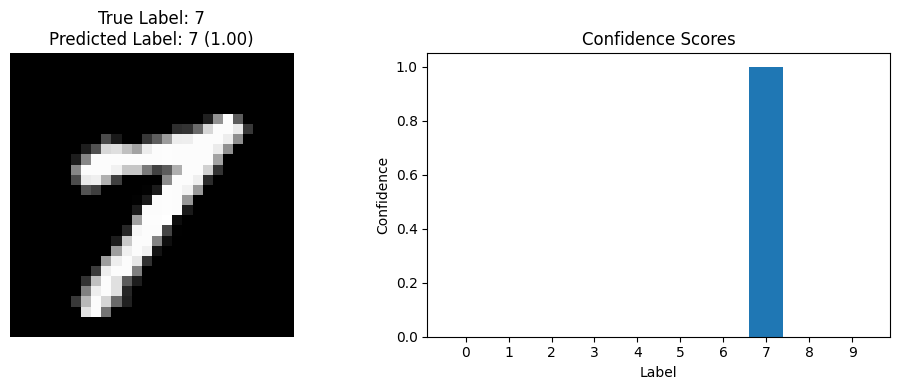

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Select a random test image
random_index = np.random.randint(0, len(test_images))
random_image = test_images[random_index]
random_label = np.argmax(test_labels[random_index])

# Make a prediction
predictions = network.predict(np.expand_dims(random_image, axis=0))
predicted_label = np.argmax(predictions[0])

# Plot the image and the confidence scores
plt.figure(figsize=(10, 4))

# Display the image
plt.subplot(1, 2, 1)
plt.imshow(random_image.reshape(28, 28), cmap='gray')
leading_confidence = predictions[0][predicted_label]
plt.title(f"True Label: {random_label}\nPredicted Label: {predicted_label} ({leading_confidence:.2f})")
plt.axis('off')

# Display the confidence scores
plt.subplot(1, 2, 2)
plt.bar(range(10), predictions[0])
plt.title("Confidence Scores")
plt.xlabel("Label")
plt.ylabel("Confidence")
plt.xticks(range(10))

plt.tight_layout()
plt.show()